In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
data_pos = pd.read_csv('result_pos1229.csv',index_col = 0)
data_size = pd.read_csv('result_size1229.csv',index_col = 0)

In [3]:
data_size

,2014,2015,2016,2017,2018,2019,2020,2021
0,2473,-1,-1,-1,-1,-1,-1,-1
1,3121,-1,-1,-1,-1,-1,-1,-1
2,9601,-1,-1,-1,-1,-1,-1,-1
3,9658,-1,-1,-1,-1,-1,-1,-1
4,936,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...
2454,-1,-1,-1,-1,-1,-1,-1,3763
2455,-1,-1,-1,-1,-1,-1,-1,118
2456,-1,-1,-1,-1,-1,-1,-1,102
2457,-1,-1,-1,-1,-1,-1,-1,2261


In [4]:
data_new = pd.DataFrame(columns = ['year','size','X','Y','match'])

In [5]:
def match(x):
    if x > 0:
        return 1
    else:
        return 0

In [42]:
k = 0 
data_new = pd.DataFrame(columns = ['year','size','X','Y','match'])
for i in tqdm(range(data_size.shape[0])):
    for j in range(data_size.shape[1]-1):
        if (1000 > data_size.iloc[i,j] > 0 and data_size.iloc[i,j-1] < 0) or (j == 0 and 1000>data_size.iloc[i,j]>0):
            data_new.loc[k] = [j+2014,data_size.iloc[i,j],data_pos.iloc[i,2*j],
                              data_pos.iloc[i,2*j+1],match(data_size.iloc[i,j+1])]
            k += 1

100%|████████████████████████████████████████████████████████████████████████████| 2459/2459 [00:01<00:00, 1247.74it/s]


In [43]:
data_new

,year,size,X,Y,match
0,2014,936,609,2470,0
1,2014,228,919,1846,0
2,2014,136,2201,6322,0
3,2014,571,2243,2820,0
4,2014,985,2359,2750,0
...,...,...,...,...,...
703,2020,571,16569,9014,0
704,2020,651,16849,14265,0
705,2020,173,16881,10898,0
706,2020,303,16935,10966,0


In [44]:
data_new.groupby('year')['match'].value_counts()

year  match
2014  0        72
      1        52
2015  0        79
      1        44
2016  0        38
      1         7
2017  0        41
      1         7
2018  0        89
      1        18
2019  0        71
      1        43
2020  0        96
      1        51
Name: match, dtype: int64

In [45]:
plaque_sum = data_new.groupby('year')['size'].count().values

In [46]:
plaque_count = []
for i in range(len(plaque_sum)):
    for j in range(2):
        plaque_count.append(plaque_sum[i])
new_plaque_matched = data_new.groupby('year')['match'].value_counts()/plaque_count

In [47]:
plaque_count

[124, 124, 123, 123, 45, 45, 48, 48, 107, 107, 114, 114, 147, 147]

In [48]:
new_plaque_matched = pd.DataFrame(new_plaque_matched)
new_plaque_matched.to_csv('new_plaque_matched.csv')

In [49]:
new_plaque_matched['count'] = data_new.groupby('year')['match'].value_counts()

In [50]:
data_new[data_new['match'] == 1].count()

year     222
size     222
X        222
Y        222
match    222
dtype: int64

In [51]:
new_plaque_matched

match  count
year match                 
2014 0      0.580645     72
     1      0.419355     52
2015 0      0.642276     79
     1      0.357724     44
2016 0      0.844444     38
     1      0.155556      7
2017 0      0.854167     41
     1      0.145833      7
2018 0      0.831776     89
     1      0.168224     18
2019 0      0.622807     71
     1      0.377193     43
2020 0      0.653061     96
     1      0.346939     51

In [52]:
possibility = []
for i in tqdm(range(1,15,2)):
    possibility.append(new_plaque_matched.iloc[i,0])

100%|██████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 7100.39it/s]


In [53]:
possibility

[0.41935483870967744,
 0.35772357723577236,
 0.15555555555555556,
 0.14583333333333334,
 0.16822429906542055,
 0.37719298245614036,
 0.3469387755102041]

Text(0.5, 1.0, 'Yearly match rate')

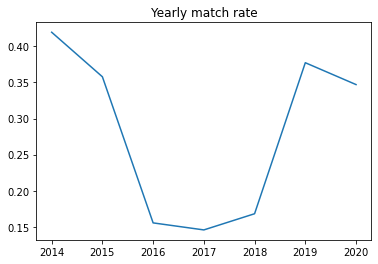

In [54]:
plt.plot(possibility)
plt.xticks(range(7),range(2014,2021))
plt.title('Yearly match rate')